# Notebook 7 — Model Evaluation & Predictions
**Project**: Real-Time Retail Analytics & Demand Prediction Platform  
**Author**: Vineet Joshi | ZDA25M007 | IIT Madras Zanzibar  

Detailed model evaluation, error analysis, saves predictions to Delta Lake, and exports best model for serving.

---

## 7.1 Install & Load

In [1]:
import sys
!{sys.executable} -m pip install deltalake pyarrow scikit-learn matplotlib seaborn mlflow joblib -q
print('Done.')

Done.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow as pa
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
from deltalake import DeltaTable
from deltalake.writer import write_deltalake

STORAGE = {
    'AWS_ENDPOINT_URL':           'http://minio:9000',
    'AWS_ACCESS_KEY_ID':          'admin',
    'AWS_SECRET_ACCESS_KEY':      'bigdata123',
    'AWS_ALLOW_HTTP':             'true',
    'AWS_S3_ALLOW_UNSAFE_RENAME': 'true',
    'AWS_REGION':                 'us-east-1'
}

print('Libraries loaded.')

Libraries loaded.


## 7.2 Load Features & Retrain Best Models

In [3]:
dt = DeltaTable('s3://retail-v2/delta/features', storage_options=STORAGE)
df = dt.to_pandas()

# Encode categoricals
le_stock   = LabelEncoder()
le_country = LabelEncoder()
df['StockCode_idx'] = le_stock.fit_transform(df['StockCode'].astype(str))
df['Country_idx']   = le_country.fit_transform(df['Country'].astype(str))

FEATURES = ['Year','Month','WeekOfYear','DayOfWeek','AvgUnitPrice',
            'NumInvoices','UniqueCustomers','TotalRevenue','StockCode_idx','Country_idx']
TARGET = 'TotalQuantity'

# Time-based split
df = df.sort_values(['Year','WeekOfYear','DayOfWeek']).reset_index(drop=True)
split = int(len(df) * 0.8)
train = df.iloc[:split]
test  = df.iloc[split:]

X_train, y_train = train[FEATURES].fillna(0), train[TARGET]
X_test,  y_test  = test[FEATURES].fillna(0),  test[TARGET]

# Train all 3 models
lr  = LinearRegression().fit(X_train, y_train)
rf  = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1).fit(X_train, y_train)
gbt = GradientBoostingRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42).fit(X_train, y_train)

lr_pred  = lr.predict(X_test)
rf_pred  = rf.predict(X_test)
gbt_pred = gbt.predict(X_test)

print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')
print('All 3 models trained.')

Train: 218,028 | Test: 54,507
All 3 models trained.


## 7.3 Detailed Evaluation Metrics

In [4]:
def full_eval(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1))) * 100
    residuals = y_true - y_pred
    return {
        'Model': name, 'RMSE': rmse, 'MAE': mae, 'R²': r2, 'MAPE': mape,
        'Mean Residual': residuals.mean(), 'Std Residual': residuals.std()
    }

eval_lr  = full_eval('Linear Regression', y_test, lr_pred)
eval_rf  = full_eval('Random Forest',     y_test, rf_pred)
eval_gbt = full_eval('Gradient Boosting',  y_test, gbt_pred)

results = pd.DataFrame([eval_lr, eval_rf, eval_gbt])
print('='*80)
print('DETAILED MODEL COMPARISON')
print('='*80)
print(results.to_string(index=False, float_format='%.4f'))

best_name = results.loc[results['R²'].idxmax(), 'Model']
print(f'\n🏆 Best model: {best_name}')

DETAILED MODEL COMPARISON
            Model     RMSE     MAE     R²     MAPE  Mean Residual  Std Residual
Linear Regression  87.9722 19.2127 0.9289 199.3543        -1.7519       87.9556
    Random Forest 293.9999  4.4442 0.2062  38.1932         1.2750      293.9999
Gradient Boosting 297.9738  2.4013 0.1846   5.9637         1.4107      297.9732

🏆 Best model: Linear Regression


## 7.4 Residual Analysis

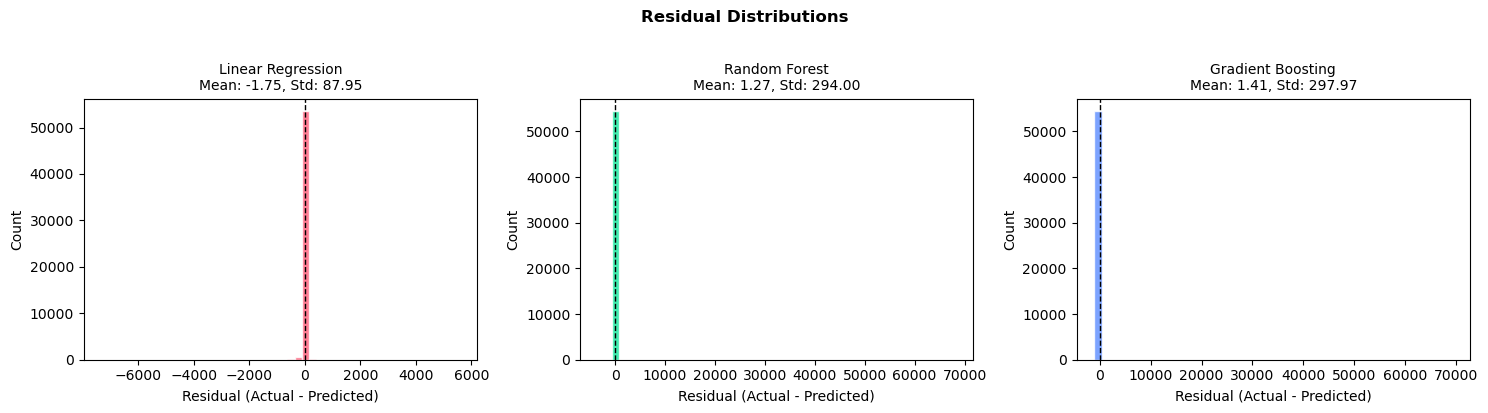

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models_data = [
    ('Linear Regression', lr_pred, '#ff5c7a'),
    ('Random Forest', rf_pred, '#10e89b'),
    ('Gradient Boosting', gbt_pred, '#5b8cff')
]

for ax, (name, pred, color) in zip(axes, models_data):
    residuals = y_test.values - pred
    ax.hist(residuals, bins=50, color=color, edgecolor='white', alpha=0.8)
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_title(f'{name}\nMean: {residuals.mean():.2f}, Std: {residuals.std():.2f}', fontsize=10)
    ax.set_xlabel('Residual (Actual - Predicted)')
    ax.set_ylabel('Count')

plt.suptitle('Residual Distributions', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/home/jovyan/work/residuals.png', dpi=150, bbox_inches='tight')
plt.show()

## 7.5 Error by Country (Best Model)

In [6]:
# Use best performing model for analysis
best_models = {'Linear Regression': lr_pred, 'Random Forest': rf_pred, 'Gradient Boosting': gbt_pred}
best_pred = best_models[best_name]

test_analysis = test.copy()
test_analysis['Predicted'] = best_pred
test_analysis['Error'] = test_analysis[TARGET] - test_analysis['Predicted']
test_analysis['AbsError'] = test_analysis['Error'].abs()

country_error = (
    test_analysis.groupby('Country')
    .agg(
        MAE=('AbsError', 'mean'),
        MeanDemand=(TARGET, 'mean'),
        Count=(TARGET, 'count')
    )
    .sort_values('Count', ascending=False)
    .head(10)
)

print(f'Error Analysis by Country ({best_name}):')
print(country_error.to_string())

Error Analysis by Country (Linear Regression):
                      MAE  MeanDemand  Count
Country                                     
United Kingdom  18.294142   22.016502  46117
France          16.417247   13.464044   1627
Germany         20.147205   16.444872   1560
EIRE            25.019495   16.413012   1368
Netherlands     45.039434   62.611399    579
Belgium         18.654490   15.094595    370
Spain           15.733695   17.625786    318
Switzerland     26.495224   20.605863    307
Norway          17.963403   26.331010    287
Portugal        18.165493   13.797794    272


## 7.6 Prediction vs Time (Weekly)

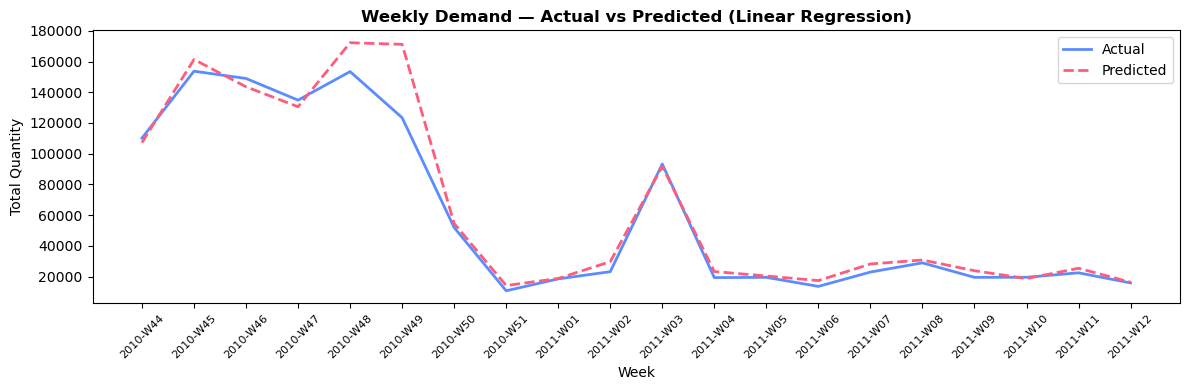

In [7]:
weekly_comp = (
    test_analysis.groupby(['Year', 'WeekOfYear'])
    .agg(
        Actual=('TotalQuantity', 'sum'),
        Predicted=('Predicted', 'sum')
    )
    .reset_index()
    .sort_values(['Year', 'WeekOfYear'])
)
weekly_comp['Week'] = weekly_comp['Year'].astype(str) + '-W' + weekly_comp['WeekOfYear'].astype(str).str.zfill(2)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(weekly_comp['Week'], weekly_comp['Actual'], label='Actual', color='#5b8cff', linewidth=2)
ax.plot(weekly_comp['Week'], weekly_comp['Predicted'], label='Predicted', color='#ff5c7a', linewidth=2, linestyle='--')
ax.set_title(f'Weekly Demand — Actual vs Predicted ({best_name})', fontweight='bold')
ax.legend()
ax.set_xlabel('Week')
ax.set_ylabel('Total Quantity')
plt.xticks(rotation=45, fontsize=8)
plt.tight_layout()
plt.savefig('/home/jovyan/work/weekly_prediction.png', dpi=150)
plt.show()

## 7.7 Save Predictions to Delta Lake

In [8]:
pred_df = test[['StockCode', 'Country', 'Year', 'Month', 'WeekOfYear', 'DayOfWeek', TARGET]].copy()
pred_df['LR_Prediction']  = lr_pred
pred_df['RF_Prediction']  = rf_pred
pred_df['GBT_Prediction'] = gbt_pred
pred_df['BestModel']      = best_name

table = pa.Table.from_pandas(pred_df, preserve_index=False)

write_deltalake(
    's3://retail-v2/delta/predictions',
    table,
    mode='overwrite',
    storage_options=STORAGE
)

print(f'✅ Predictions saved to s3://retail-v2/delta/predictions')
print(f'   Rows: {len(pred_df):,}')
print(f'   Columns: {pred_df.columns.tolist()}')

✅ Predictions saved to s3://retail-v2/delta/predictions
   Rows: 54,507
   Columns: ['StockCode', 'Country', 'Year', 'Month', 'WeekOfYear', 'DayOfWeek', 'TotalQuantity', 'LR_Prediction', 'RF_Prediction', 'GBT_Prediction', 'BestModel']


## 7.8 Export Best Model

In [9]:
MODEL_PATH = '/home/jovyan/work/best_model.joblib'

# Export the best model
best_model_obj = {'Linear Regression': lr, 'Random Forest': rf, 'Gradient Boosting': gbt}[best_name]
joblib.dump(best_model_obj, MODEL_PATH)

# Also save encoders and feature list
joblib.dump({
    'model': best_model_obj,
    'le_stock': le_stock,
    'le_country': le_country,
    'features': FEATURES,
    'target': TARGET,
    'model_name': best_name
}, '/home/jovyan/work/model_bundle.joblib')

import os
print(f'✅ Best model exported: {MODEL_PATH}')
print(f'   Model: {best_name}')
print(f'   Size:  {os.path.getsize(MODEL_PATH)/1024:.1f} KB')
print(f'   Bundle: /home/jovyan/work/model_bundle.joblib')

✅ Best model exported: /home/jovyan/work/best_model.joblib
   Model: Linear Regression
   Size:  1.2 KB
   Bundle: /home/jovyan/work/model_bundle.joblib


## 7.9 Verify Predictions in Delta Lake

In [10]:
dt_pred = DeltaTable('s3://retail-v2/delta/predictions', storage_options=STORAGE)
print(f'Delta predictions table:')
print(f'  Version: {dt_pred.version()}')
print(f'\nSample predictions:')
dt_pred.to_pandas().head(5)

Delta predictions table:
  Version: 0

Sample predictions:


,StockCode,Country,Year,Month,WeekOfYear,DayOfWeek,TotalQuantity,LR_Prediction,RF_Prediction,GBT_Prediction,BestModel
0,22617,United Kingdom,2010,11,44,2,18,57.254947,12.053808,19.232174,Linear Regression
1,22618,United Kingdom,2010,11,44,2,1,-5.264773,3.930220,0.832727,Linear Regression
2,22619,United Kingdom,2010,11,44,2,8,10.251208,7.017409,7.999132,Linear Regression
3,22620,United Kingdom,2010,11,44,2,14,4.474586,11.674349,13.105293,Linear Regression
4,22622,United Kingdom,2010,11,44,2,2,3.337039,3.955687,1.911952,Linear Regression


## 7.10 Summary

In [11]:
print('='*55)
print('NOTEBOOK 7 COMPLETE')
print('='*55)
print(f'  Best model       : {best_name}')
print(f'  R² score         : {results.loc[results["R²"].idxmax(), "R²"]:.4f}')
print(f'  RMSE             : {results.loc[results["R²"].idxmax(), "RMSE"]:.4f}')
print(f'  Predictions saved: s3://retail-v2/delta/predictions ({len(pred_df):,} rows)')
print(f'  Model exported   : best_model.joblib + model_bundle.joblib')
print()
print('Artifacts:')
print('  residuals.png')
print('  weekly_prediction.png')
print('  best_model.joblib')
print('  model_bundle.joblib')
print()
print('Next: Notebook 8 — Real-Time Interactive Dashboard')

NOTEBOOK 7 COMPLETE
  Best model       : Linear Regression
  R² score         : 0.9289
  RMSE             : 87.9722
  Predictions saved: s3://retail-v2/delta/predictions (54,507 rows)
  Model exported   : best_model.joblib + model_bundle.joblib

Artifacts:
  residuals.png
  weekly_prediction.png
  best_model.joblib
  model_bundle.joblib

Next: Notebook 8 — Real-Time Interactive Dashboard
